<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-45-decision-trees-intuition-code?scriptVersionId=349543892" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 🌳 ML 46 — Decision Trees | Entropy & Gini
---

# Geometric Intuition

# Advantages & Disadvantages

# CART

# Game Example

# What is Entropy

# Gini Impurity

In [1]:
import pandas as pd
from pandas_datareader import data
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor

from sklearn.model_selection import train_test_split
from sklearn import metrics

from sklearn.metrics import r2_score
from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import GridSearchCV

In [2]:
california = fetch_california_housing(as_frame=True)

X = california.data
y = california.target

In [3]:
df = california.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [5]:
rt = DecisionTreeRegressor(criterion ='squared_error', max_depth=5)

rt.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=5)

In [6]:
y_pred = rt.predict(X_test)

r2_score(y_test,y_pred)

0.6018796993971511

In [7]:
from sklearn.model_selection import RandomizedSearchCV

# Model
model = DecisionTreeRegressor(random_state=42)

# Hyperparameter space
param_grid = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 3, 5, 10, 15, 20, 25, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8, 10],
    'max_features': [None, 'sqrt', 'log2']
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

# IMPORTANT: Fit only on training data
random_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(random_search.best_params_)

# Best cross-validation score
print("\nBest CV R² Score:")
print(random_search.best_score_)

# Best model
best_rt = random_search.best_estimator_

# Test set prediction
y_pred = best_rt.predict(X_test)

# Final test score
print("\nTest R² Score:")
print(r2_score(y_test, y_pred))

Best Parameters:
{'splitter': 'random', 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': None, 'max_depth': None, 'criterion': 'poisson'}

Best CV R² Score:
0.6852967010571989

Test R² Score:
0.6815642589344081


# Feature Importance

In [8]:
for importance, name in sorted(zip(rt.feature_importances_, X_train.columns), reverse=True):
  print (name, importance)

MedInc 0.7757851141692362
AveOccup 0.1381601199618186
HouseAge 0.03800727368038256
AveRooms 0.024144269949551857
Latitude 0.01942068395769317
Population 0.003599267969757248
AveBedrms 0.0008832703115603884
Longitude 0.0


In [9]:
!pip install -q dtreeviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 1.2 MB/s eta 0:00:00


In [10]:
from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    plot_tree
)

import dtreeviz

In [11]:
# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names = iris.target_names.tolist()

In [12]:
clf = DecisionTreeClassifier(
    random_state=42
)

clf.fit(X, y)

DecisionTreeClassifier(random_state=42)

# Visualize using `plot_tree()`

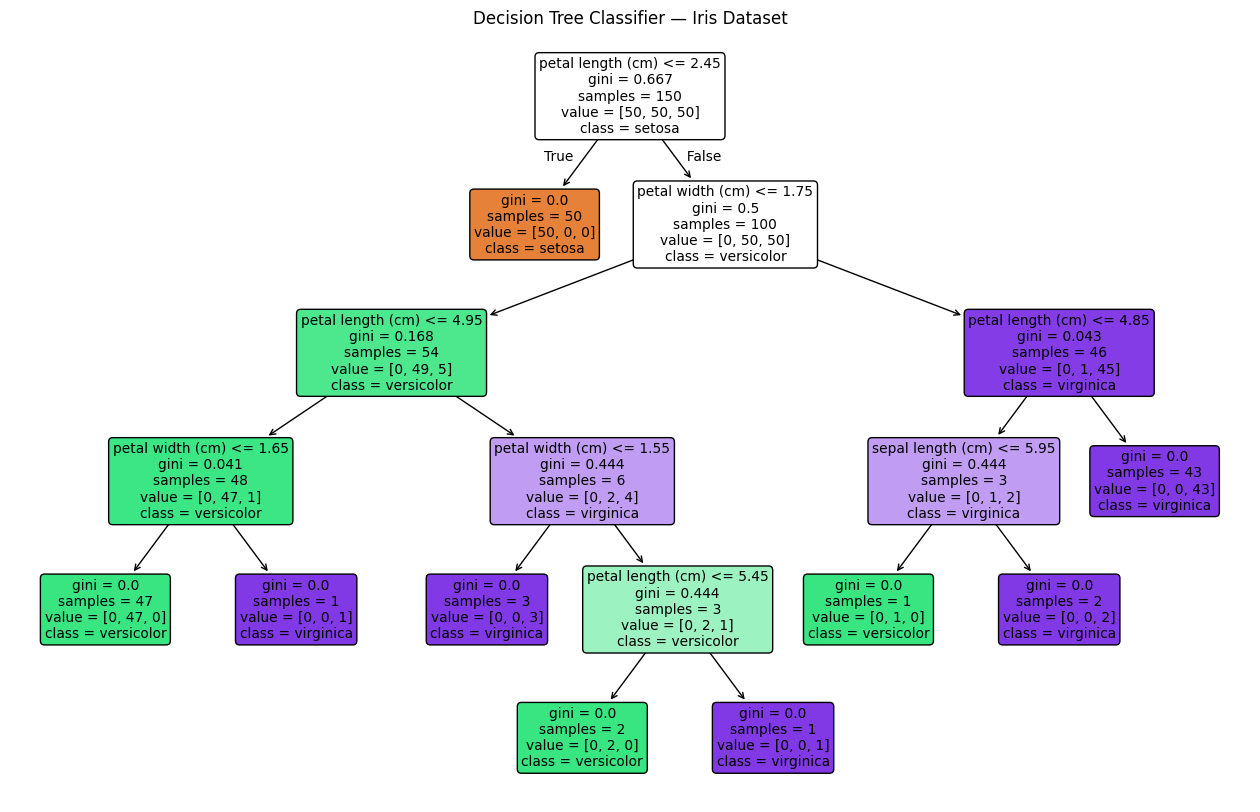

In [13]:
plt.figure(figsize=(16, 10))

plot_tree(
    clf,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    impurity=True
)

plt.title("Decision Tree Classifier — Iris Dataset")
plt.show()

# Visualize using `dtreeviz`

In [14]:
plt.rcParams.update({
    "font.family": "DejaVu Sans"
})

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

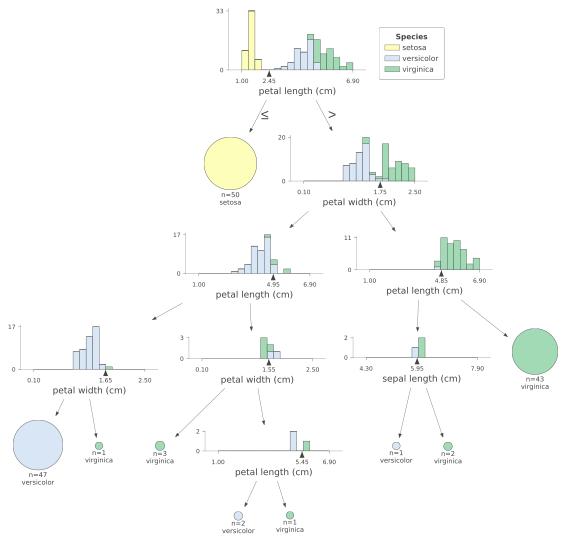

In [15]:
viz_model = dtreeviz.model(
    clf,
    X_train=X,
    y_train=y,
    feature_names=feature_names,
    target_name="Species",
    class_names=class_names
)

viz_model.view()

# Explain a Single Prediction

In [16]:
sample_index = np.random.randint(len(iris.data))
sample = iris.data[sample_index]

print("Sample:")
print(sample)

print("\nActual class:")
print(iris.target_names[iris.target[sample_index]])

print("\nPredicted class:")
print(iris.target_names[clf.predict([sample])[0]])

Sample:
[5.2 4.1 1.5 0.1]

Actual class:
setosa

Predicted class:
setosa


In [17]:
'''
clas = tree.DecisionTreeClassifier()  
iris = load_iris()

X_train = iris.data
y_train = iris.target
clas.fit(X_train, y_train)

X = iris.data[np.random.randint(0, len(iris.data)),:]

viz = dtreeviz.model(clas, 
               X_train,
               y_train,
               feature_names=iris.feature_names, 
               class_names=["setosa", "versicolor", "virginica"], 
               X=X)
viz
'''

'\nclas = tree.DecisionTreeClassifier()  \niris = load_iris()\n\nX_train = iris.data\ny_train = iris.target\nclas.fit(X_train, y_train)\n\nX = iris.data[np.random.randint(0, len(iris.data)),:]\n\nviz = dtreeviz.model(clas, \n               X_train,\n               y_train,\n               feature_names=iris.feature_names, \n               class_names=["setosa", "versicolor", "virginica"], \n               X=X)\nviz\n'

# 3-D Regression

In [18]:
'''
from mpl_toolkits.mplot3d import Axes3D
from sklearn.tree import DecisionTreeRegressor
from dtreeviz.trees import *


figsize = (6,5)
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111, projection='3d')

t = rtreeviz_bivar_3D(rt,
                      X, y,
                      feature_names=['MedInc', 'AveOccup'],
                      target_name='MedHouseVal',
                      fontsize=14,
                      elev=20,
                      azim=25,
                      dist=8.2,
                      show={'splits','title'},
                      ax=ax)
plt.show()
'''

"\nfrom mpl_toolkits.mplot3d import Axes3D\nfrom sklearn.tree import DecisionTreeRegressor\nfrom dtreeviz.trees import *\n\n\nfigsize = (6,5)\nfig = plt.figure(figsize=figsize)\nax = fig.add_subplot(111, projection='3d')\n\nt = rtreeviz_bivar_3D(rt,\n                      X, y,\n                      feature_names=['MedInc', 'AveOccup'],\n                      target_name='MedHouseVal',\n                      fontsize=14,\n                      elev=20,\n                      azim=25,\n                      dist=8.2,\n                      show={'splits','title'},\n                      ax=ax)\nplt.show()\n"